In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd

In [23]:
DS_PATH = "../data/raw/urbansound8k/"

In [24]:
df = pd.read_csv(f"{DS_PATH}UrbanSound8K.csv")

/tmp/ipykernel_56181/1782389876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


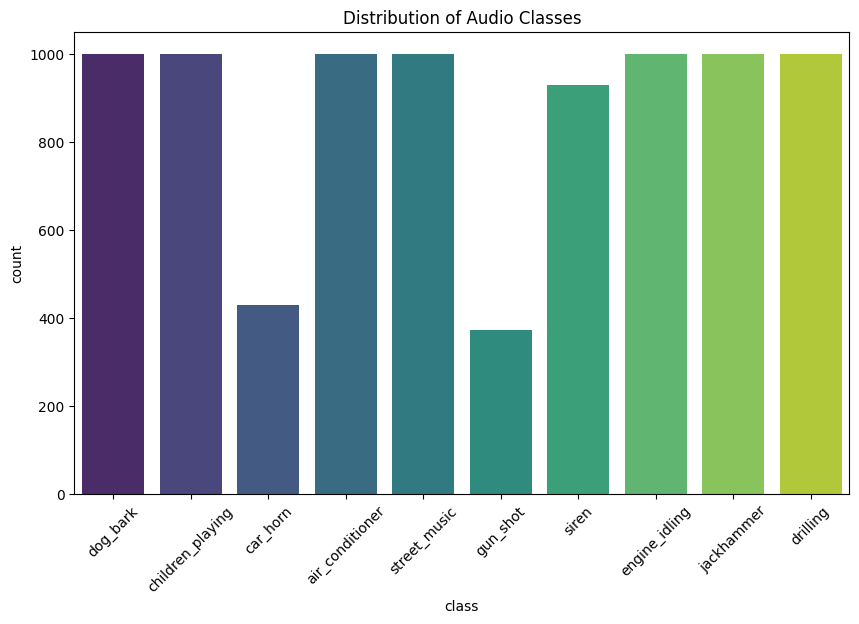

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Distribution of Audio Classes')
plt.xticks(rotation=45)
plt.show()

In [26]:
df['duration'] = df['end'] - df['start']
print(df['duration'].describe())

count    8732.000000
mean        3.607904
std         0.973570
min         0.054517
25%         4.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: duration, dtype: float64


In [27]:
def plot_audio_analysis(file_path, class_label):
    # Load audio file (resampled to 22.05kHz by default)
    data, sr = librosa.load(file_path)
    
    # Create the figure
    plt.figure(figsize=(12, 10))
    
    # Add a main title for the whole plot
    plt.suptitle(f"Class: {class_label}", fontsize=16, fontweight='bold')
    
    # 1. Plot Waveform
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(data, sr=sr)
    plt.title(f'Waveform - {class_label}')
    plt.ylabel('Amplitude')
    
    # 2. Plot Mel-Spectrogram
    plt.subplot(2, 1, 2)
    S = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f'Mel-Spectrogram - {class_label}')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()

In [30]:
row = df.sample(1).iloc[0]
path = f"{DS_PATH}fold{row['fold']}/{row['slice_file_name']}"

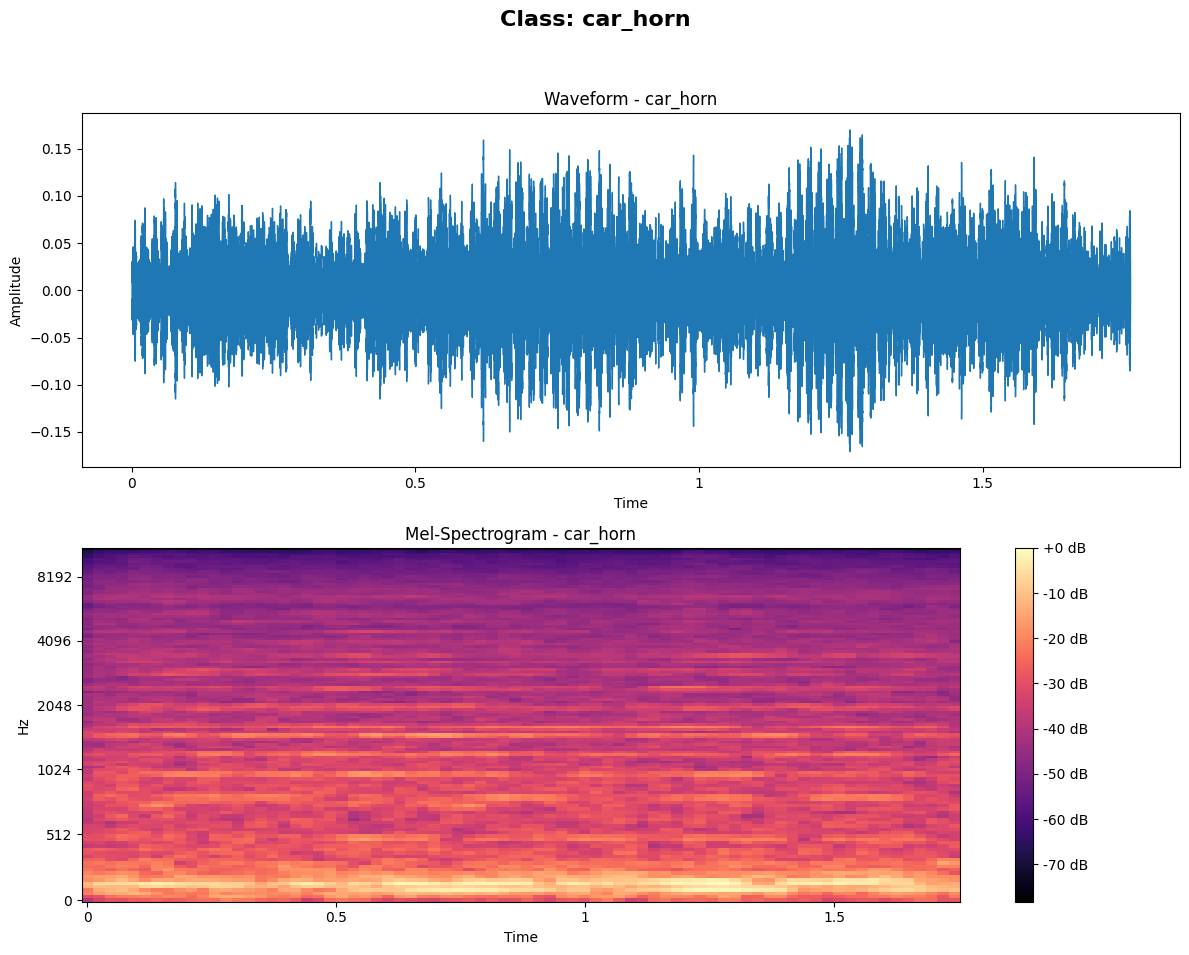

In [31]:
plot_audio_analysis(path, row['class'])